In [19]:
#Python
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

In [20]:
#Load the CSV file
df = pd.read_csv("Nat_Gas.csv")


In [21]:
#Display the first few rows
df.head()

,Dates,Prices
0,10/31/20,10.1
1,11/30/20,10.3
2,12/31/20,11.0
3,1/31/21,10.9
4,2/28/21,10.9


In [22]:
#Convert the Dates Column into datetime
df["Dates"] = pd.to_datetime(df["Dates"])

C:\Users\abuha\AppData\Local\Temp\ipykernel_5944\2403159742.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dates"] = pd.to_datetime(df["Dates"])


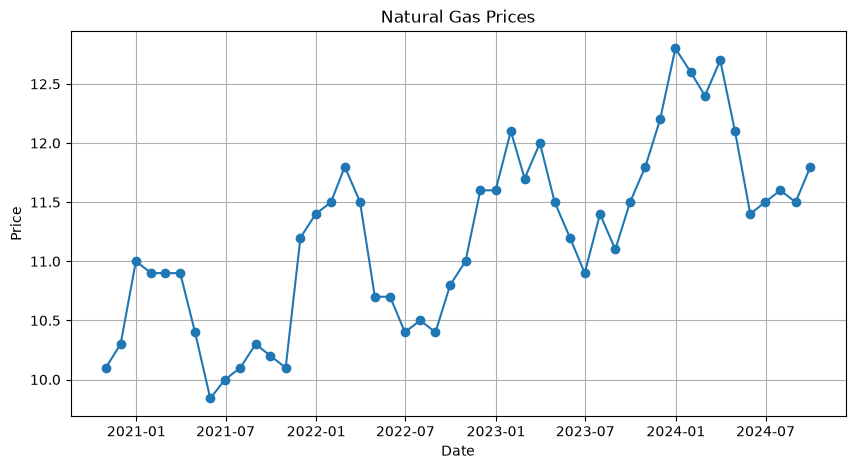

In [23]:
#Plot the data
plt.figure(figsize=(10,5)) 
plt.plot(df["Dates"], df["Prices"], marker="o")
plt.title("Natural Gas Prices") 
plt.xlabel("Date") 
plt.ylabel("Price") 
plt.grid(True) 
plt.show()

In [26]:
#Convert Dates To Numeric Values
origin = df["Dates"].min()
x = (df["Dates"] - origin).dt.days
y = df["Prices"]

In [29]:
#Create the interpolation model
spline = CubicSpline(x, y)

In [30]:
#Estimate the price for a specific date
date = pd.to_datetime("2022-06-15")
days = (date - origin).days
price = spline(days)
print(price) 

10.553878500511676


In [31]:
#Calculate monthly seasonality
df["Month"] = df["Dates"].dt.month
monthly_avg = df.groupby("Month")["Prices"].mean()
overall_avg = df["Prices"].mean()
seasonality = monthly_avg - overall_avg


In [32]:
#Calculate the trend
years = (df["Dates"].max() - origin).days / 365.25
trend_per_year = (y.iloc[-1] - y.iloc[0]) / years
print(trend_per_year)

0.43421328671328696


In [33]:
#Create the prediction function
def estimate_price(date_string):
    target = pd.to_datetime(date_string)
    if target <= df["Dates"].max():
        days = (target - origin).days
        return float(spline(days))
    years_ahead = (target - df["Dates"].max()).days / 365.25
    base = y.iloc[-1] + trend_per_year * years_ahead
    adjustment = seasonality[target.month]
    return float(base + adjustment)

    
    

In [34]:
#Test the function
print(estimate_price("2023-07-15"))
print(estimate_price("2025-04-20"))


11.150044532231151
12.00805652680653


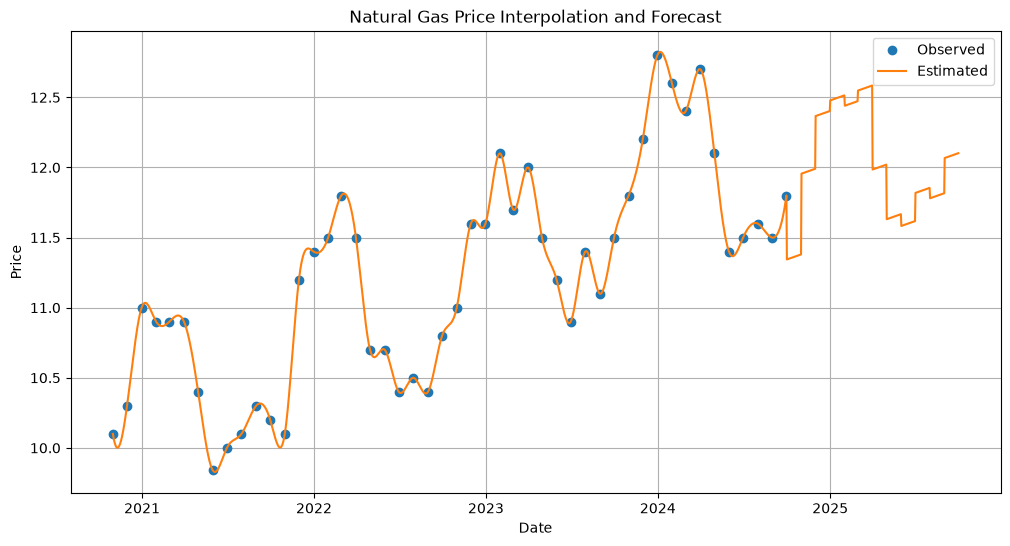

In [44]:
#Plot historical data and the one-year forecast

future_dates = pd.date_range(
    start=df["Dates"].min(),
    end=df["Dates"].max() + pd.DateOffset(years=1),
    freq="D" 
)

future_prices = [estimate_price(str(d.date())) for d in future_dates]

plt.figure(figsize=(12,6))
plt.plot(df["Dates"], df["Prices"], "o", label ="Observed")
plt.plot(future_dates, future_prices, label="Estimated")
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Natural Gas Price Interpolation and Forecast")
plt.legend()
plt.grid(True)
plt.show()